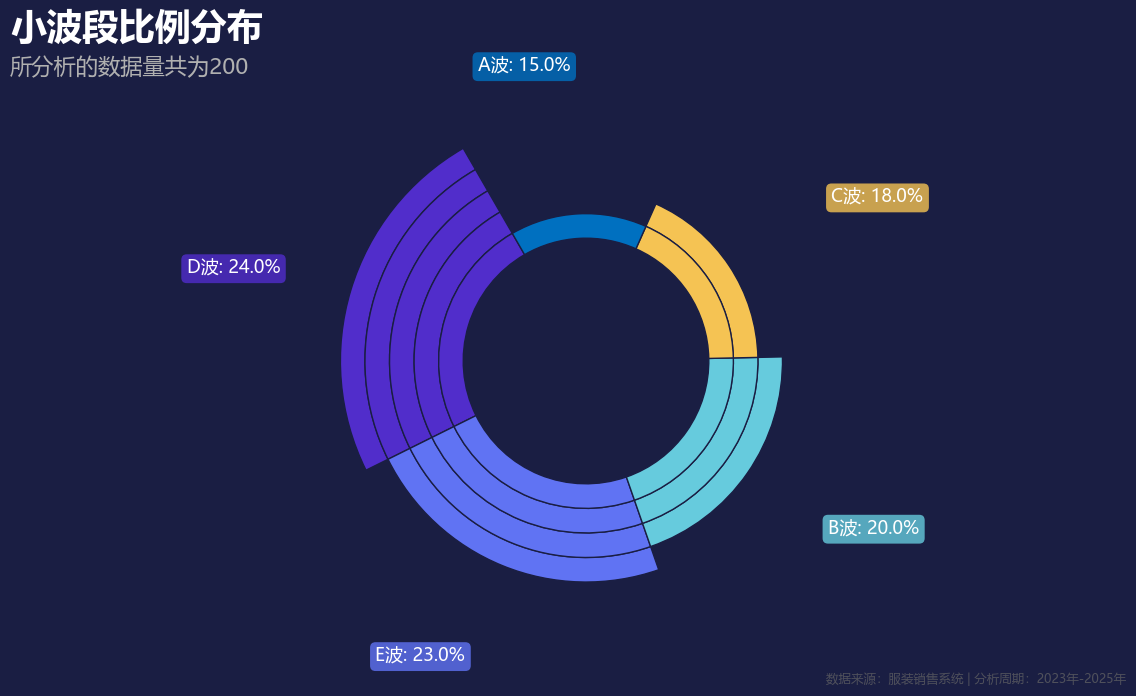

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']  # 支持中文
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

try:
    # 读取数据
    df_spu = pd.read_csv("../../数据生成/spu_manages_feishu.csv", encoding="utf-8-sig")

    # 提取"小波段"列并统计频次
    element_counts = df_spu["小波段"].value_counts().reset_index()
    element_counts.columns = ["小波段", "数量"]
    
    # 过滤掉空值（如果存在）
    element_counts = element_counts[element_counts["小波段"].notna()]
    
    # 计算占比，并按数量排序
    total = element_counts["数量"].sum()
    element_counts['比例'] = element_counts["数量"] / total
    element_counts.sort_values(by='数量', ascending=False, inplace=True)

    # 定义颜色
    colors = [
        "#512DCB",  # 紫
        "#6073F3",  # 淡紫
        "#66CBDD",  # 青
        "#F5C353",  # 金黄
        "#0070C0"   # 蓝
    ]
    
    # 初始化 wedges
    wedges = []
    
    # 创建画布与子图（深色背景）
    fig, ax = plt.subplots(figsize=(12, 7))
    BACKGROUND_COLOR = "#1A1E43"
    fig.patch.set_facecolor(BACKGROUND_COLOR)
    ax.set_facecolor(BACKGROUND_COLOR)

    # 绘制多层环形图，每层对应一个圆环
    num_layers = len(element_counts)
    for layer in range(num_layers):
        layer_width = 0.1
        wedges, _ = ax.pie(
            element_counts["数量"],
            labels=None,
            colors=colors,
            startangle=120,
            radius=1 - layer * layer_width,
            wedgeprops=dict(width=layer_width, edgecolor=BACKGROUND_COLOR),
            explode=[0] * len(element_counts)
        )
        # 只填充当前层的前 `layer + 1` 个扇区
        for wedge in wedges[layer + 1:]:
            wedge.set_visible(False)
        
    # 添加外部标签而不包含引线
    for i, (wedge, label) in enumerate(zip(wedges, element_counts["小波段"])):
        angle = (wedge.theta2 - wedge.theta1) / 2.0 + wedge.theta1
        x = np.cos(np.deg2rad(angle))
        y = np.sin(np.deg2rad(angle))
        horizontalalignment = 'left' if x >= 0 else 'right'

        # 根据比例设置外部标签位置
        proportion = element_counts['比例'].iloc[i]

        # 如果是紫色或淡紫色，进行特殊处理以延长初始起始位置
        offset = 0.1 if colors[i] in ["#512DCB", "#6073F3"] else 0  # 调整偏移量
        
        ax.text(
            x * (1.2 + offset), y * (1.2 + offset),  # 使用比例位置
            f"{label}: {proportion:.1%}",
            color='white',
            fontsize=13,
            ha=horizontalalignment,
            va='center',
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor=colors[i],
                edgecolor='none',
                alpha=0.8
            )
        )

    # 设置标题
    plt.figtext(0.02, 0.95, "小波段比例分布",
                ha='left', fontsize=26, color='#ffffff', fontweight='bold')
    plt.figtext(0.02, 0.9, f"所分析的数据量共为{total}", 
                ha='left', fontsize=16, color='#B0B0B0')
        
    # 添加数据来源说明
    plt.figtext(0.95, 0.03,
                '数据来源：服装销售系统 | 分析周期：2023年-2025年',
                ha='right', fontsize=9, color='#666666', alpha=0.7)

    # 设置图表属性
    ax.set_aspect('equal', adjustable='box')
    ax.axis('off')

    # 调整布局
    plt.tight_layout(rect=(0.05, 0.03, 0.95, 0.95))

    # 保存图像
    plt.savefig("小波段比例分布.png", dpi=300, bbox_inches='tight', facecolor=BACKGROUND_COLOR)

    # 显示图表
    plt.show()

except Exception as e:
    print(f"图表生成失败: {str(e)}")
    raise

# 分析

- **D波**（紫色）：
  占比24.0%，为各波段中占比最高的部分，表明D波段在样本中占据显著地位，可能与该波段的特性或应用场景相关。

- **E波**（浅紫色）：
  占比23.0%，略低于D波，显示出E波段同样具有较高的市场份额，可能反映了相似的市场偏好或应用需求。

- **B波**（青色）：
  占比20.0%，位居第三，表明B波段在样本中也占据了较大的比例，可能与特定的市场需求或技术特性有关。

- **C波**（金黄色）：
  占比18.0%，显示出C波段在市场中的稳定需求，可能与特定的技术应用或市场细分有关。

- **A波**（蓝色）：
  占比15.0%，为各波段中占比最低的部分，尽管比例最小，但仍然显示出A波段在市场中的存在，可能与特定的高端应用或小众市场有关。


# 结论

从小波段的比例分布来看，D波和E波占据了较大的市场份额，显示出这两个波段在市场中的重要性。B波和C波也显示出稳定的市场需求，而A波虽然占比最小，但仍然具有一定的市场存在。这种分布可能指示了不同波段在技术应用、市场需求或消费者偏好方面的差异。